# Assignment: Advance Regression

## Surprise Housing Case

### Problem Statement:
Surprise Housing, which is US based company, aspires to enter into the Autralian Market. They have obtained housing data set of the Australian market and wants to analyze which is the significant variable in predicting the price of a house. 

In order to arrive at the solution, we will follow following steps as has been taught in the lectures:

1. Reading & Understanding the data
2. Data Cleaning
3. Preparing the data for modelling
4. Model building and evaluation

### 1. Reading & Understanding the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

import os

# hide warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
#importing the dataset
surprise = pd.read_csv("C:/Users/Polu/Desktop/Data Science Course/Advance Regression Case Study/train.csv")
surprise.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
#Looking at the number of rows & columns
surprise.shape

(1460, 81)

In [4]:
#We will drop the Id, as this is just a repitition of serial number
surprise=surprise.drop("Id", axis=1)

In [5]:
#Checking missing data info and type of data
surprise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
MSSubClass       1460 non-null int64
MSZoning         1460 non-null object
LotFrontage      1201 non-null float64
LotArea          1460 non-null int64
Street           1460 non-null object
Alley            91 non-null object
LotShape         1460 non-null object
LandContour      1460 non-null object
Utilities        1460 non-null object
LotConfig        1460 non-null object
LandSlope        1460 non-null object
Neighborhood     1460 non-null object
Condition1       1460 non-null object
Condition2       1460 non-null object
BldgType         1460 non-null object
HouseStyle       1460 non-null object
OverallQual      1460 non-null int64
OverallCond      1460 non-null int64
YearBuilt        1460 non-null int64
YearRemodAdd     1460 non-null int64
RoofStyle        1460 non-null object
RoofMatl         1460 non-null object
Exterior1st      1460 non-null object
Exterior2nd      1460 non-

In [6]:
#coverting datatype of MSSubclass as it is a categorical column
surprise.MSSubClass = surprise.MSSubClass.astype(str)

In [7]:
# verify duplicates in the data set 
surprise[surprise.duplicated()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [8]:
#On visual inspection we can see that there are lots of columns in NaN values, lets explore them
_temp = pd.DataFrame ((surprise.isnull().sum(axis=0) / surprise.shape[0]).round(4))
_temp.columns=["Per_Missing"]
_temp["Per_Missing"] =_temp["Per_Missing"] *100
_temp["col_types"] = surprise[_temp.index].dtypes
_temp[_temp.Per_Missing != 0].sort_values(by="Per_Missing",ascending =False)

,Per_Missing,col_types
PoolQC,99.52,object
MiscFeature,96.30,object
Alley,93.77,object
Fence,80.75,object
FireplaceQu,47.26,object
LotFrontage,17.74,float64
GarageType,5.55,object
GarageYrBlt,5.55,float64
GarageFinish,5.55,object
GarageQual,5.55,object


### 2. Data Cleaning

In [9]:
#Univarate Analysis of data with missing values
#We are dropping columns with more than 40% of the missing values
surprise=surprise.drop(["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"], axis=1)

In [10]:
#We will also drop GarageYrBlt, as intuitively it does not serve any purpose. Age of property is more important
surprise=surprise.drop("GarageYrBlt", axis=1)

In [11]:
#Out of the remaining items, LotFrontage and MasVnrArea are numerical columns, Lets explore the data
surprise[["LotFrontage", "MasVnrArea"]].describe()

,LotFrontage,MasVnrArea
count,1201.000000,1452.000000
mean,70.049958,103.685262
std,24.284752,181.066207
min,21.000000,0.000000
25%,59.000000,0.000000
50%,69.000000,0.000000
75%,80.000000,166.000000
max,313.000000,1600.000000


In [12]:
#In case of LotFrontage, we can impute the missing values with mean
#In case of MasVnrArea, we cannot find any pattern between the area of the flat and MasVnrArea.
# In such a case and as the number of missing data is very small, we will impute it with the median value
surprise["LotFrontage"].fillna((surprise["LotFrontage"].mean()), inplace=True)
surprise["MasVnrArea"].fillna((surprise["MasVnrArea"].median()), inplace=True)

In [13]:
#of the remaining items,we will first study the four categories, as others are sub-categories of remaining category
surprise['GarageType'].astype('category').value_counts()

Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: GarageType, dtype: int64

In [14]:
surprise['BsmtExposure'].astype('category').value_counts()

No    953
Av    221
Gd    134
Mn    114
Name: BsmtExposure, dtype: int64

In [15]:
surprise['MasVnrType'].astype('category').value_counts()

None       864
BrkFace    445
Stone      128
BrkCmn      15
Name: MasVnrType, dtype: int64

In [16]:
surprise['Electrical'].astype('category').value_counts()

SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: Electrical, dtype: int64

In [17]:
#We will thus impute these variables with the mode
#In case of MasVnrType, it is logical as we have imputed MasVnrArea with median which is Zero
surprise.GarageType =surprise.GarageType.fillna("Attchd")
surprise.BsmtExposure =surprise.BsmtExposure.fillna("No")
surprise.MasVnrType =surprise.MasVnrType.fillna("None")
surprise.Electrical =surprise.Electrical.fillna("SBrkr")

In [18]:
#We will not study the remaining categorical variables
surprise['GarageFinish'].astype('category').value_counts()

Unf    605
RFn    422
Fin    352
Name: GarageFinish, dtype: int64

In [19]:
surprise['GarageQual'].astype('category').value_counts()

TA    1311
Fa      48
Gd      14
Po       3
Ex       3
Name: GarageQual, dtype: int64

In [20]:
surprise['GarageCond'].astype('category').value_counts()

TA    1326
Fa      35
Gd       9
Po       7
Ex       2
Name: GarageCond, dtype: int64

In [21]:
#We will thus impute these variables with the mode
surprise.GarageFinish =surprise.GarageFinish.fillna("Unf")
surprise.GarageQual =surprise.GarageQual.fillna("TA")
surprise.GarageCond =surprise.GarageCond.fillna("TA")

In [22]:
#Studying remaining variables with respect to basement
surprise['BsmtFinType2'].astype('category').value_counts()

Unf    1256
Rec      54
LwQ      46
BLQ      33
ALQ      19
GLQ      14
Name: BsmtFinType2, dtype: int64

In [23]:
surprise['BsmtFinType1'].astype('category').value_counts()

Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
Name: BsmtFinType1, dtype: int64

In [24]:
surprise['BsmtCond'].astype('category').value_counts()

TA    1311
Gd      65
Fa      45
Po       2
Name: BsmtCond, dtype: int64

In [25]:
surprise['BsmtQual'].astype('category').value_counts()

TA    649
Gd    618
Ex    121
Fa     35
Name: BsmtQual, dtype: int64

In [26]:
#As we have selected no basement exposure, we will thus impute these variables with No Exspoure
surprise.BsmtFinType2 =surprise.BsmtFinType2.fillna("No Exposure")
surprise.BsmtFinType1 =surprise.BsmtFinType1.fillna("No Exposure")
surprise.BsmtCond =surprise.BsmtCond.fillna("No Exposure")
surprise.BsmtQual =surprise.BsmtQual.fillna("No Exposure")

### Outlier Check

In [27]:
surprise[['LotFrontage', 'LotArea', 'OverallQual', 
          'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 
          'BsmtFinSF1', 'BsmtFinSF2']].describe()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315
std,22.024023,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273
min,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000
25%,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000
50%,70.049958,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000
75%,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000
max,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000


We can find the age of the property from YearBuilt and age of remodelling from YearRemodAdd and then drop these variables as it does not add much value in isolation

In [28]:
surprise[['BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
          'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']].describe()

,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877
std,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885
min,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000
25%,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000
50%,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000
75%,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000
max,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000


None of the data looks out of place here

In [29]:
surprise[['BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea',
          'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch']].describe()

,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,2.866438,1.046575,6.517808,0.613014,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589
std,0.815778,0.220338,1.625393,0.644666,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331
min,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,5.000000,0.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,1.000000,6.000000,1.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000
75%,3.000000,1.000000,7.000000,1.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000
max,8.000000,3.000000,14.000000,3.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000


None of the data looks out of place here

In [30]:
surprise[['ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']].describe()

,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


We can find period since last sold from YrSold and then drop MoSold and YrSold as they intituitively do not add much value in isolation

In [31]:
#We will first add a derived variable age of the property from YearBuilt before we change it to object datatype
surprise['PropAge'] = 2019 - surprise['YearBuilt']
surprise['RemodelAge'] = 2019 - surprise['YearRemodAdd']
surprise['LastSold'] = 2019 - surprise['YrSold']

In [32]:
#Lets check the data
surprise.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PropAge,RemodelAge,LastSold
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,2,2008,WD,Normal,208500,16,16,11
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,5,2007,WD,Normal,181500,43,43,12
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,9,2008,WD,Normal,223500,18,17,11
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,2,2006,WD,Abnorml,140000,104,49,13
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,12,2008,WD,Normal,250000,19,19,11


In [33]:
#Dropping redundant variables
surprise=surprise.drop(["YearBuilt", "YearRemodAdd", "MoSold","YrSold"], axis=1)

In [34]:
#rechecking columns
surprise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 73 columns):
MSSubClass       1460 non-null object
MSZoning         1460 non-null object
LotFrontage      1460 non-null float64
LotArea          1460 non-null int64
Street           1460 non-null object
LotShape         1460 non-null object
LandContour      1460 non-null object
Utilities        1460 non-null object
LotConfig        1460 non-null object
LandSlope        1460 non-null object
Neighborhood     1460 non-null object
Condition1       1460 non-null object
Condition2       1460 non-null object
BldgType         1460 non-null object
HouseStyle       1460 non-null object
OverallQual      1460 non-null int64
OverallCond      1460 non-null int64
RoofStyle        1460 non-null object
RoofMatl         1460 non-null object
Exterior1st      1460 non-null object
Exterior2nd      1460 non-null object
MasVnrType       1460 non-null object
MasVnrArea       1460 non-null float64
ExterQual        146

Looks fine

### Further Data Exploration

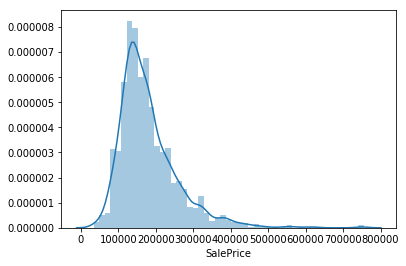

In [35]:
# Target variable: Price of House
sns.distplot(surprise['SalePrice'])
plt.show()

The above plot shows that the data is positively skewed with a long tail, which is absolutely correct as few properties will be available at a higher price than at the lower price. Now with the regression model we will try to find out which are the variables which impact it more than others

In [ ]:
# pairwise scatter plot to see the relationship between variables

plt.figure(figsize=(20, 10))
sns.pairplot(surprise)
plt.show()

In [37]:
# correlation matrix
cor = surprise.corr()
cor

,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice,PropAge,RemodelAge,LastSold
LotFrontage,1.000000,0.306795,0.234196,-0.052820,0.178699,0.215828,0.043340,0.122156,0.363358,0.414266,...,0.137454,0.009790,0.062335,0.037684,0.180868,0.001168,0.334901,-0.117598,-0.082746,-0.006768
LotArea,0.306795,1.000000,0.105806,-0.005636,0.103321,0.214103,0.111170,-0.002618,0.260833,0.299475,...,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.263843,-0.014228,-0.013788,0.014261
OverallQual,0.234196,0.105806,1.000000,-0.091932,0.407252,0.239666,-0.059119,0.308159,0.537808,0.476224,...,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.790982,-0.572323,-0.550684,0.027347
OverallCond,-0.052820,-0.005636,-0.091932,1.000000,-0.125694,-0.046231,0.040229,-0.136841,-0.171098,-0.144203,...,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.077856,0.375983,-0.073741,-0.043950
MasVnrArea,0.178699,0.103321,0.407252,-0.125694,1.000000,0.261256,-0.071330,0.113862,0.360067,0.339850,...,0.122528,-0.109907,0.019144,0.062248,0.011928,-0.029512,0.472614,-0.311600,-0.176529,0.008317
BsmtFinSF1,0.215828,0.214103,0.239666,-0.046231,0.261256,1.000000,-0.050117,-0.495251,0.522396,0.445863,...,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,0.386420,-0.249503,-0.128451,-0.014359
BsmtFinSF2,0.043340,0.111170,-0.059119,0.040229,-0.071330,-0.050117,1.000000,-0.209294,0.104810,0.097117,...,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.011378,0.049107,0.067759,-0.031706
BsmtUnfSF,0.122156,-0.002618,0.308159,-0.136841,0.113862,-0.495251,-0.209294,1.000000,0.415360,0.317987,...,0.129005,-0.002538,0.020764,-0.012579,-0.035092,-0.023837,0.214479,-0.149040,-0.181133,0.041258
TotalBsmtSF,0.363358,0.260833,0.537808,-0.171098,0.360067,0.522396,0.104810,0.415360,1.000000,0.819530,...,0.247264,-0.095478,0.037384,0.084489,0.126053,-0.018479,0.613581,-0.391452,-0.291066,0.014969
1stFlrSF,0.414266,0.299475,0.476224,-0.144203,0.339850,0.445863,0.097117,0.317987,0.819530,1.000000,...,0.211671,-0.065292,0.056104,0.088758,0.131525,-0.021096,0.605852,-0.281986,-0.240379,0.013604


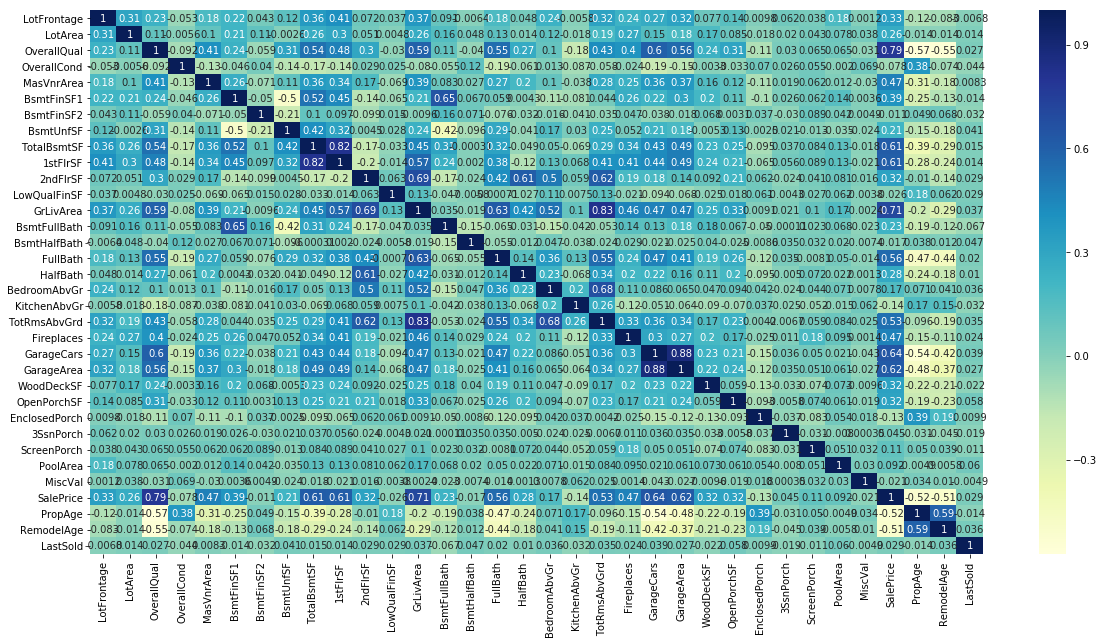

In [38]:
# plotting correlations on a heatmap

# figure size
plt.figure(figsize=(20,10))

# heatmap
sns.heatmap(cor, cmap="YlGnBu", annot=True)
plt.show()

From observing the heat map, we get following insights about the correlation of price with independent variables:
1. Price is highy correlated with overall qauality, GrLivArea, garage cars, garage area, total basement sq feet, 1st floor sq. ft;
2. Similarly, it highly negatively correlared with age of the property and time since last remodelling
3. Thus, the dataset suffers from multicollinearity issue

### 3. Preparing the data for modelling

In [39]:
#relooking at columns to create x and y variable
surprise.columns.tolist()

['MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'GarageType',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'Sal

In [40]:
# split the data into X and y
X = surprise.loc[:, ['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour',
                 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
                 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 
                 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
                 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
                 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
                 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                 'ScreenPorch', 'PoolArea', 'MiscVal', 'SaleType', 'SaleCondition', 'PropAge', 'RemodelAge', 'LastSold']]

y = surprise['SalePrice']

In [41]:
# creating dummy variables for categorical variables

# subset all categorical variables
surprise_categorical = X.select_dtypes(include=['object'])
surprise_categorical.head()

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
1,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,SBrkr,TA,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
2,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
3,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,SBrkr,Gd,Typ,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal


In [42]:
# convert into dummies
surprise_dummies = pd.get_dummies(surprise_categorical, drop_first=True)
surprise_dummies.head()

,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0


In [43]:
# drop categorical variables 
X = X.drop(list(surprise_categorical.columns), axis=1)

In [44]:
# concat dummy variables with X
X = pd.concat([X, surprise_dummies], axis=1)

In [45]:
# scaling the features
from sklearn.preprocessing import scale

# storing column names in cols, after scaling (the df is converted to a numpy array)
cols = X.columns
X = pd.DataFrame(scale(X))
X.columns = cols
X.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=247)

From 1460 x 81 dataset, we have moved on to 1460 x 247 dataset, after creating dummy variables and modelling will be carried out on this dataset

In [46]:
#Coverting y into dataframe for scaling the values of sales price
y = pd.DataFrame(data=y)
y.head()

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


In [47]:
# scaling the features
from sklearn.preprocessing import scale

cols1 = y.columns
y = pd.DataFrame(scale(y))
y.columns = cols1
y.columns

Index(['SalePrice'], dtype='object')

In [48]:
#rechecking scaled y
y.head()

,SalePrice
0,0.347273
1,0.007288
2,0.536154
3,-0.515281
4,0.869843


In [49]:
# split into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7,
                                                    test_size = 0.3, random_state=100)

### 4. Model Building & Evaluation

#### We will just try Linear Regression and look at R2

In [50]:
# We will first try linear regression & see the results
lm = LinearRegression()
lm.fit(X_train, y_train)

# predict
from sklearn.metrics import r2_score
y_train_pred = lm.predict(X_train)
r2_score(y_true=y_train, y_pred=y_train_pred)

0.9493876549046261

In [51]:
y_test_pred = lm.predict(X_test)
r2_score(y_true=y_test, y_pred=y_test_pred)

-2.1302456358897522e+21

The r2 figure for train and test data clearly shows a huge difference and why linear regression cannot be used

#### Ridge Regression: We will try to solve this problem using regularisation technique 

In [52]:
# list of alphas to tune
params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 
 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 
 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500, 1000 ]}


ridge = Ridge()

# cross validation
folds = 5
model_cv = GridSearchCV(estimator = ridge, 
                        param_grid = params, 
                        scoring= 'r2', 
                        cv = folds, 
                        return_train_score=True,
                        verbose = 1)            
model_cv.fit(X_train, y_train)
#We have chosen r2 as scoring method, as we can instantly know the which model fits better

Fitting 5 folds for each of 28 candidates, totalling 140 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 140 out of 140 | elapsed:    2.2s finished


GridSearchCV(cv=5, error_score='raise-deprecating',
       estimator=Ridge(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=None,
   normalize=False, random_state=None, solver='auto', tol=0.001),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500, 1000]},
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='r2', verbose=1)

In [53]:
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results = cv_results[cv_results['param_alpha']<=200]
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.007353,0.001550,0.000794,0.000680,0.0001,{'alpha': 0.0001},0.846804,0.559882,0.692853,0.237880,...,0.644289,0.233494,28,0.956535,0.951308,0.953420,0.953154,0.954413,0.953766,0.001710
1,0.014007,0.005716,0.001159,0.002318,0.001,{'alpha': 0.001},0.846816,0.559889,0.692875,0.238032,...,0.644328,0.233444,27,0.956535,0.951308,0.953420,0.953154,0.954413,0.953766,0.001710
2,0.013777,0.005120,0.000952,0.000563,0.01,{'alpha': 0.01},0.846936,0.559957,0.693101,0.239542,...,0.644717,0.232949,26,0.956535,0.951308,0.953420,0.953154,0.954412,0.953766,0.001710
3,0.009086,0.000944,0.003036,0.001454,0.05,{'alpha': 0.05},0.847461,0.560245,0.694092,0.246178,...,0.646421,0.230775,25,0.956533,0.951307,0.953418,0.953153,0.954411,0.953765,0.001710
4,0.008543,0.000526,0.003223,0.001611,0.1,{'alpha': 0.1},0.848097,0.560574,0.695301,0.254304,...,0.648500,0.228121,24,0.956528,0.951306,0.953413,0.953148,0.954407,0.953761,0.001709


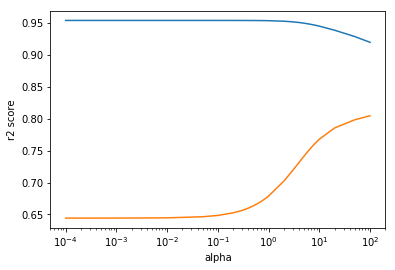

In [54]:
# plotting r2 with alpha
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('r2 score')
plt.xscale('log')
plt.show()

In [55]:
#We chosen 100 as the optimum alpha for ridge regression
alpha = 100
ridge = Ridge(alpha=alpha)

ridge.fit(X_train, y_train)

# predict
y_train_pred = ridge.predict(X_train)
print(r2_score(y_true=y_train, y_pred=y_train_pred))
y_test_pred = ridge.predict(X_test)
print(r2_score(y_true=y_test, y_pred=y_test_pred))

0.9143620699698243
0.8562483875065432


For the given alpha, the r2 comes out to be very good and not much difference between train and test r2

#### Lasso: We have chosen Lasso Regression as it helps in feature selection and will cut down on the process of RfE

In [56]:
# grid search CV

# set up cross validation scheme
from sklearn.model_selection import KFold
folds = KFold(n_splits = 5, shuffle = True, random_state = 4)

# specifying range of hyperparameters
params = {'alpha': [0.001, 0.01, 1.0, 5.0, 10.0]}

# grid search
# lasso model
model = Lasso()
model_cv = GridSearchCV(estimator = model, param_grid = params, 
                        scoring= 'r2', 
                        cv = folds, 
                        return_train_score=True, verbose = 1)            
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:    1.2s finished


GridSearchCV(cv=KFold(n_splits=5, random_state=4, shuffle=True),
       error_score='raise-deprecating',
       estimator=Lasso(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=1000,
   normalize=False, positive=False, precompute=False, random_state=None,
   selection='cyclic', tol=0.0001, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'alpha': [0.001, 0.01, 1.0, 5.0, 10.0]},
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='r2', verbose=1)

In [57]:
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.167766,0.036736,0.000633,0.000859,0.001,{'alpha': 0.001},0.658501,0.808119,0.874944,0.189179,...,0.687327,0.263162,2,0.956601,0.946529,0.952087,0.952706,0.950347,0.951654,0.003278
1,0.028223,0.002859,0.000722,0.001011,0.01,{'alpha': 0.01},0.685921,0.818267,0.882407,0.330993,...,0.723763,0.210309,1,0.918582,0.896411,0.907221,0.936137,0.904330,0.912536,0.013778
2,0.012029,0.001699,0.001421,0.000473,1,{'alpha': 1.0},-0.000146,-0.000012,-0.004028,-0.005445,...,-0.002013,0.002271,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.008121,0.006052,0.001288,0.001720,5,{'alpha': 5.0},-0.000146,-0.000012,-0.004028,-0.005445,...,-0.002013,0.002271,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.009075,0.002705,0.003213,0.001490,10,{'alpha': 10.0},-0.000146,-0.000012,-0.004028,-0.005445,...,-0.002013,0.002271,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


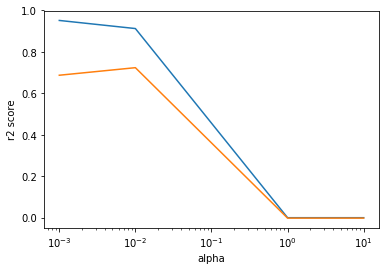

In [58]:
# plotting r2 with alpha
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('r2 score')
plt.xscale('log')
plt.show()

In [59]:
# model with optimal alpha at 0.01 for lasso regression
# lasso regression with aplha = 0.01, as this is where alpha is highest and difference between alpha nd r2 is minimum
# Both the above conditions are fulfilled simulataneously and we get the optimum r2 for train and test data
lm = Lasso(alpha=0.01)
lm.fit(X_train, y_train)

# predict
y_train_pred = lm.predict(X_train)
print(r2_score(y_true=y_train, y_pred=y_train_pred))
y_test_pred = lm.predict(X_test)
print(r2_score(y_true=y_test, y_pred=y_test_pred))

0.8984095155797768
0.8429488267145351


In [60]:
# lasso model parameters
model_parameters = list(lm.coef_)
model_parameters.insert(0, lm.intercept_)
cols = X.columns
cols = cols.insert(0, "constant")
list(zip(cols, model_parameters))

[('constant', array([-0.00725529])),
 ('LotFrontage', -0.0),
 ('LotArea', 0.044499176012910605),
 ('OverallQual', 0.19651036422250284),
 ('OverallCond', 0.04055991017678913),
 ('MasVnrArea', 0.03139654166491101),
 ('BsmtFinSF1', 0.0),
 ('BsmtFinSF2', 0.0),
 ('BsmtUnfSF', -0.0),
 ('TotalBsmtSF', 0.022462507529346202),
 ('1stFlrSF', 0.0),
 ('2ndFlrSF', 0.0),
 ('LowQualFinSF', -0.018144686603840065),
 ('GrLivArea', 0.35531644877951357),
 ('BsmtFullBath', 0.04624581775501241),
 ('BsmtHalfBath', 0.0),
 ('FullBath', 0.03069708811266678),
 ('HalfBath', 0.0),
 ('BedroomAbvGr', -0.007295955327621788),
 ('KitchenAbvGr', -0.05219236588574122),
 ('TotRmsAbvGrd', 0.0),
 ('Fireplaces', 0.022947024911404674),
 ('GarageCars', 0.08077174442865617),
 ('GarageArea', 0.0),
 ('WoodDeckSF', 0.012674427606591742),
 ('OpenPorchSF', 0.0),
 ('EnclosedPorch', -0.0),
 ('3SsnPorch', 0.0038517702471703515),
 ('ScreenPorch', 0.00601152557580347),
 ('PoolArea', -0.003924984212160688),
 ('MiscVal', -0.0),
 ('PropAge',

#### Inference & Recommendation:
a) We have chosen to go ahead with the output given by Lasso regression, as Lasso has reduced complexity by variable selection, and the r2 is also comparable to that of ridge regression. Further, on account of large value of alpha for ridge regression, test error will be high, as the model will not have captured the behaviour of the data correctly. Thus, it has less complexity and will perform better than ridge regression.

b) With respect to the query of the company w.r.t.the important predictor variables, we can surmise that the following variables are directly proportional to the price of a house in descending order of importance:
1. GrLivArea: Above grade (ground) living area square feet
2. OverallQual: Rates the overall material and finish of the house
3. Neighborhood: Northridge
4. Neighborhood: Northridge Heights
5. GarageCars: Size of garage in car capacity

The following variables are inversely proportional to the price of the property in descending order of importance:
1. Age of the property
2. KitchenQual: Typical/Average
3. KitchenQual: Good (Implies buyers always look for excellent quality of kitchen!)
4. BsmtQual Gd: Evaluates the height of the basement (even if it is Good, people are not willing to pay higher price for house)
5. Condition2: Adjacent to postive off-site feature (people do not prefer to live adjacent to parks, greenbelts etc.)